<div align=center>
    <h1><b>Asesmen CLO Semester Genap 2024/2025</b></h1>
    <h1><b>Pemodelan dan Optimasi Lanjut</b></h1>
</div>

### Kelas : S2IF-48-01

### Anggota Kelompok
|Nama|NIM|
|----|---|
|Muhammad Abiya Makruf|203012420034|
|Muhammad Rafly Arjasubrata|203012420028|
|Nugroho Rahmanto|203012420029|

Environment :
- Python 3.12.7
- Numpy 1.26.4

# **Soal 1**
Sebuah perusahaan PT. ABC bergerak dibidang manufaktur yang mempunyai relatif banyak karyawan. Pihak HRD dari perusahaan ini ingin melakukan studi terkait dengan produktivitas dari kerja karyawannya, dalam rangka meningkatkan produktivitas perusahaan secara umum. Perusahaan ingin mengetahui hubungan antara jumlah jam kerja lembur dan jumlah pelatihan teknis terhadap produktivitas kerja karyawan. Berikut ini adalah data survey terhadap 15 karyawan perusahaan tersebut, dimana di catat jumlah jam kerja lembur per-minggu, jumlah jam pelatihan teknis yang diterima, dan skor produktivitas kerja karyawan (skala 1-100):

| Karyawan | Lembur (Jam) | Pelatihan Teknis (Jam) | Skor Produktivitas |
|----------|--------------|------------------------|---------------------|
| 1        | 4            | 6                      | 78                  |
| 2        | 5            | 8                      | 85                  |
| 3        | 3            | 5                      | 75                  |
| 4        | 7            | 7                      | 88                  |
| 5        | 2            | 4                      | 72                  |
| 6        | 6            | 5                      | 83                  |
| 7        | 8            | 9                      | 91                  |
| 8        | 5            | 7                      | 86                  |
| 9        | 9            | 8                      | 92                  |
| 10       | 4            | 5                      | 80                  |
| 11       | 6            | 6                      | 84                  |
| 12       | 7            | 10                     | 90                  |
| 13       | 3            | 3                      | 70                  |
| 14       | 8            | 8                      | 89                  |
| 15       | 5            | 6                      | 82                  |

### **Pertanyaan/Tugas**
1. Buatlah model regresi multivariat untuk mengetahui hubungan antar ajumlah jam kerja lembur dan jumlah jam pelatihan teknis terhadap skor produktivitas kerja karyawan.
2. Hitung bobot regresi (vektor bobot *$w$*) menggunakan regresi multivariat.
3. Berikan persamaan regresi yang diperoleh dan iterpretasikan hasil bobot regresi yang didapatkan.

<u>Petunjuk</u>: Lakukan regresi multivariat dengan variabel bebas: Lembur ($x_1$) dan Pelatihan Teknis ($x_2$), dengan Skor Produktivitas ($y$) sebagai variabel target/dependent, dimana model regresi direpresentasikan sebagai formula :

**$f(x) = Xw$**

Dimana $f(x)$ adalah target/variabel dependent, $X$ adalah matriks input, dan $w$ adalah vektor/matriks bobot. Hitung variabel $W$ (bobot) dengan formula multivariative regression.

## **Jawaban No.1**

In [3]:
# Import numpy untuk operasi matematika dengan matriks
import numpy as np
# Import matplotlib untuk visualisasi data
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D # Import untuk plot 3D
# Import pandas untuk membuat visualisasi tabel data
import pandas as pd

In [4]:
# Buat dataset dalam bentuk array numpy
data = np.array([
    [1, 4, 6, 78],
    [2, 5, 8, 85],
    [3, 3, 5, 75],
    [4, 7, 7, 88],
    [5, 2, 4, 72],
    [6, 6, 5, 83],
    [7, 8, 9, 91],
    [8, 5, 7, 86],
    [9, 9, 8, 92],
    [10, 4, 5, 80],
    [11, 6, 6, 84],
    [12, 7, 10, 90],
    [13, 3, 3, 70],
    [14, 8, 8, 89],
    [15, 5, 6, 82]
])

In [5]:
# Split fitur dan target
X = data[:, 1:3]
y = data[:, 3].reshape(-1, 1)

print("Fitur (X):")
print(X)
print("Ukuran matriks fitur :", X.shape)

print("\nTarget (y):")
print(y)
print("Ukuran matriks target :", y.shape)

Fitur (X):
[[ 4  6]
 [ 5  8]
 [ 3  5]
 [ 7  7]
 [ 2  4]
 [ 6  5]
 [ 8  9]
 [ 5  7]
 [ 9  8]
 [ 4  5]
 [ 6  6]
 [ 7 10]
 [ 3  3]
 [ 8  8]
 [ 5  6]]
Ukuran matriks fitur : (15, 2)

Target (y):
[[78]
 [85]
 [75]
 [88]
 [72]
 [83]
 [91]
 [86]
 [92]
 [80]
 [84]
 [90]
 [70]
 [89]
 [82]]
Ukuran matriks target : (15, 1)


In [6]:
# Inisialisasi matriks bias dengan nilai 1
bias = np.ones((X.shape[0], 1))

# Gabungkan fitur dan bias
X = np.hstack((bias, X)) # Bias di kolom pertama
print("\nFitur dengan bias (X):")
print(X)


Fitur dengan bias (X):
[[ 1.  4.  6.]
 [ 1.  5.  8.]
 [ 1.  3.  5.]
 [ 1.  7.  7.]
 [ 1.  2.  4.]
 [ 1.  6.  5.]
 [ 1.  8.  9.]
 [ 1.  5.  7.]
 [ 1.  9.  8.]
 [ 1.  4.  5.]
 [ 1.  6.  6.]
 [ 1.  7. 10.]
 [ 1.  3.  3.]
 [ 1.  8.  8.]
 [ 1.  5.  6.]]


Rumus yang digunakan :

$\bar{w} = (X^T X)^{-1} X^T y$

In [7]:
# Hitung bobot w menggunakan rumus w = (X^T * X)^(-1) * X^T * y

# 1. Transpose X (X^T)
XT = X.T

# 2. Perkalian matriks X^T dengan X (X^T X)
XTX = np.dot(XT, X)

# 3. Inverse dari (X^T X) -> (X^T X)^(-1)
XTX_inv = np.linalg.inv(XTX)

# 4. Perkalian matriks X^T dengan y (X^T y)
XTy = np.dot(XT, y)

# 5. Hitung bobot w = (X^T X)^(-1) (X^T y)
w = np.dot(XTX_inv, XTy)

print("Hasil Perhitungan Bobot Regresi (w)")
print("Vektor Bobot (w):\n", w)

Hasil Perhitungan Bobot Regresi (w)
Vektor Bobot (w):
 [[62.25      ]
 [ 2.00634058]
 [ 1.51268116]]


In [ ]:
# Buat prediksi menggunakan bobot w
y_pred = np.dot(X, w)

print("Skor Produktivitas Aktual (y):\n", y.flatten())
print("Skor Produktivitas Prediksi (y_pred):\n", y_pred.flatten())

# Hitung Metrik Evaluasi
errors = y - y_pred
mse = np.mean(errors**2)
rmse = np.sqrt(mse)
mae = np.mean(np.abs(errors))
mape = np.mean(np.abs(errors.flatten() / y.flatten())) * 100

print("\nMetrik Evaluasi:")
print(f"Mean Squared Error (MSE)    : {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"Mean Absolute Error (MAE)     : {mae:.4f}")
print(f"Mean Absolute Percentage Error (MAPE): {mape:.2f}%")

Skor Produktivitas Aktual (y):
 [78 85 75 88 72 83 91 86 92 80 84 90 70 89 82]
Skor Produktivitas Prediksi (y_pred):
 [79.35144928 84.38315217 75.83242754 86.88315217 72.3134058  81.85144928
 91.91485507 82.87047101 92.40851449 77.83876812 83.36413043 91.42119565
 72.80706522 90.40217391 81.35778986]

Metrik Evaluasi:
Mean Squared Error (MSE)    : 2.2477
Root Mean Squared Error (RMSE): 1.4992
Mean Absolute Error (MAE)     : 1.2601
Mean Absolute Percentage Error (MAPE): 1.54%


In [9]:
# Ekstrak bobot
intercept = w[0, 0]
coef_lembur = w[1, 0]
coef_pelatihan = w[2, 0]

print(f"Persamaan Regresi:")
print(f"Skor_Produktivitas = {intercept:.4f} + {coef_lembur:.4f} * Lembur + {coef_pelatihan:.4f} * Pelatihan_Teknis")

print("\nNilai Bobot Regresi:")
print(f"Intercept (b0)                  : {intercept:.4f}")
print(f"Koefisien Lembur (b1)           : {coef_lembur:.4f}")
print(f"Koefisien Pelatihan Teknis (b2) : {coef_pelatihan:.4f}")

print("\nInterpretasi Bobot Regresi:")
print(f"- Intercept ({intercept:.4f}): Ini adalah nilai prediksi skor produktivitas ketika jumlah jam lembur dan jumlah jam pelatihan teknis keduanya adalah 0. Secara praktis mungkin kurang bermakna jika karyawan tidak mungkin memiliki 0 jam lembur dan 0 jam pelatihan, namun secara matematis ini adalah titik potong pada sumbu Y.")
print(f"- Koefisien Lembur ({coef_lembur:.4f}): Setiap penambahan 1 jam kerja lembur per minggu, dengan asumsi jumlah jam pelatihan teknis konstan, diprediksi akan meningkatkan skor produktivitas rata-rata sebesar {coef_lembur:.4f} poin.")
print(f"- Koefisien Pelatihan Teknis ({coef_pelatihan:.4f}): Setiap penambahan 1 jam pelatihan teknis, dengan asumsi jumlah jam kerja lembur konstan, diprediksi akan meningkatkan skor produktivitas rata-rata sebesar {coef_pelatihan:.4f} poin.")

Persamaan Regresi:
Skor_Produktivitas = 62.2500 + 2.0063 * Lembur + 1.5127 * Pelatihan_Teknis

Nilai Bobot Regresi:
Intercept (b0)                  : 62.2500
Koefisien Lembur (b1)           : 2.0063
Koefisien Pelatihan Teknis (b2) : 1.5127

Interpretasi Bobot Regresi:
- Intercept (62.2500): Ini adalah nilai prediksi skor produktivitas ketika jumlah jam lembur dan jumlah jam pelatihan teknis keduanya adalah 0. Secara praktis mungkin kurang bermakna jika karyawan tidak mungkin memiliki 0 jam lembur dan 0 jam pelatihan, namun secara matematis ini adalah titik potong pada sumbu Y.
- Koefisien Lembur (2.0063): Setiap penambahan 1 jam kerja lembur per minggu, dengan asumsi jumlah jam pelatihan teknis konstan, diprediksi akan meningkatkan skor produktivitas rata-rata sebesar 2.0063 poin.
- Koefisien Pelatihan Teknis (1.5127): Setiap penambahan 1 jam pelatihan teknis, dengan asumsi jumlah jam kerja lembur konstan, diprediksi akan meningkatkan skor produktivitas rata-rata sebesar 1.5127 poin.


In [ ]:
# Ambil data yang relevan
karyawan_id = data[:, 0].astype(int)
lembur_aktual = X[:, 0]
pelatihan_aktual = X[:, 1]
skor_aktual = y.flatten()
skor_prediksi = y_pred.flatten()

# Buat DataFrame
df_results = pd.DataFrame({
    'Karyawan': karyawan_id,
    'Lembur (Jam)': lembur_aktual,
    'Pelatihan Teknis (Jam)': pelatihan_aktual,
    'Skor Produktivitas (Aktual)': skor_aktual,
    'Skor Produktivitas (Prediksi)': skor_prediksi.round(2),
    'Error': np.abs(skor_aktual - skor_prediksi).round(2)
})

print("\nTabel Perbandingan Hasil Prediksi dan Nilai Aktual")
df_results


Tabel Perbandingan Hasil Prediksi dan Nilai Aktual


,Karyawan,Lembur (Jam),Pelatihan Teknis (Jam),Skor Produktivitas (Aktual),Skor Produktivitas (Prediksi),Error
0,1,1.0,4.0,78,79.35,1.35
1,2,1.0,5.0,85,84.38,0.62
2,3,1.0,3.0,75,75.83,0.83
3,4,1.0,7.0,88,86.88,1.12
4,5,1.0,2.0,72,72.31,0.31
5,6,1.0,6.0,83,81.85,1.15
6,7,1.0,8.0,91,91.91,0.91
7,8,1.0,5.0,86,82.87,3.13
8,9,1.0,9.0,92,92.41,0.41
9,10,1.0,4.0,80,77.84,2.16


Visualisasi Plot 3D untuk Bidang Regresi Multivariat


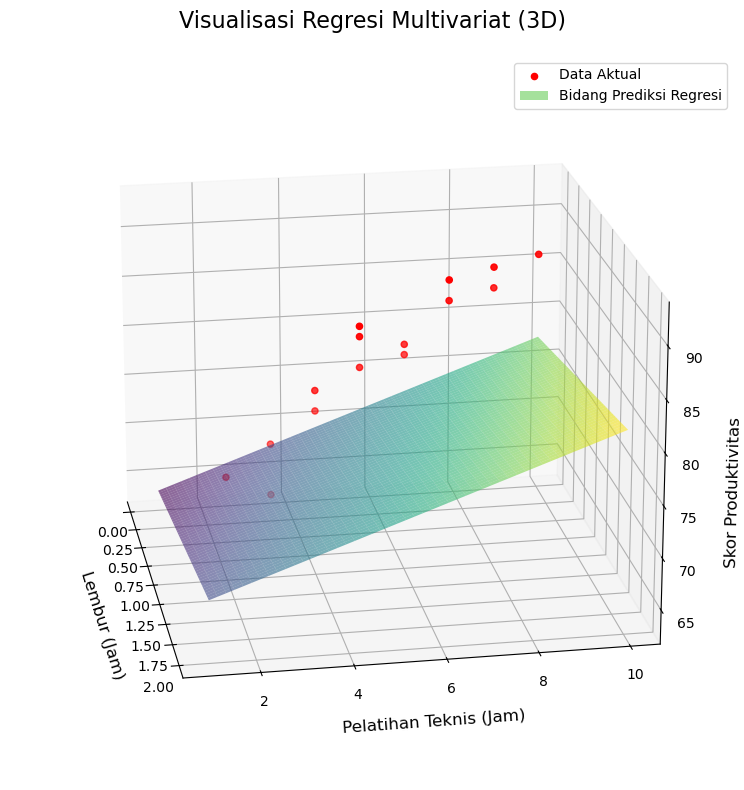

In [23]:
print("Visualisasi Plot 3D untuk Bidang Regresi Multivariat")
# Inisialisasi figure
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot data aktual
ax.scatter(lembur_aktual,
           pelatihan_aktual,
           skor_aktual,
           color='red',
           label='Data Aktual')

# Buat grid
x_surf = np.linspace(lembur_aktual.min() - 1, lembur_aktual.max() + 1, 50)
y_surf = np.linspace(pelatihan_aktual.min() - 1, pelatihan_aktual.max() + 1, 50)
xx, yy = np.meshgrid(x_surf, y_surf)

# Hitung nilai Skor Produktivitas Prediksi untuk bidang prediksi
z_pred_surf = intercept + coef_lembur * xx + coef_pelatihan * yy

# Plot bidang regresi
ax.plot_surface(xx, yy, z_pred_surf, cmap='viridis', alpha=0.6, edgecolor='none', label='Bidang Prediksi Regresi')

ax.set_xlabel('Lembur (Jam)', fontsize=12, labelpad=10)
ax.set_ylabel('Pelatihan Teknis (Jam)', fontsize=12, labelpad=10)
ax.set_zlabel('Skor Produktivitas', fontsize=12, labelpad=10)
ax.set_title('Visualisasi Regresi Multivariat (3D)', fontsize=16, pad=20)
ax.view_init(elev=20, azim=-10)
ax.legend(fontsize=10)

# Tampilkan plot
plt.tight_layout()
plt.show()